# Race to Planet Fitness

Using the sensor logger app data, creating a notional racing line and calculating the fastest way to get there and deviations from the "track centerline".

In [1]:
telemetry_db = 'race_to_planet_fitness.sqlite'

In [2]:
from haversine import haversine
import sqlite3
import duckdb
import pandas as pd

def migrate_location_table(sqlite_path, duckdb_path, csv_path, from_seconds=None, to_seconds=None):
    # Connect to SQLite database
    print(f"Connecting to SQLite database at {sqlite_path}...")
    sqlite_conn = sqlite3.connect(sqlite_path)
    
    # Read data using pandas
    print("Reading Location table from SQLite...")
    df = pd.read_sql_query("SELECT * FROM Location", sqlite_conn)
    print(f"Initial data loaded. Row count: {len(df)}")
    
    if 'seconds_elapsed' in df.columns:
        # Remove rows with negative seconds_elapsed
        print(f"Removing rows with negative seconds_elapsed... (before: {len(df)} rows)")
        df = df[df['seconds_elapsed'] >= 0]
        print(f"After removal: {len(df)} rows")
        
        # Filter by seconds_elapsed if parameters are provided
        if from_seconds is not None:
            print(f"Filtering data with seconds_elapsed >= {from_seconds}...")
            df = df[df['seconds_elapsed'] >= from_seconds]
            
        if to_seconds is not None:
            print(f"Filtering data with seconds_elapsed <= {to_seconds}...")
            df = df[df['seconds_elapsed'] <= to_seconds]
            
        print(f"After time range filtering: {len(df)} rows")
        
        # Sort by time to ensure chronological order
        print("Sorting data chronologically...")
        df = df.sort_values('seconds_elapsed')
        
        # Detect and remove GPS anomalies
        print("Detecting and removing GPS anomalies...")
        # Calculate distance between consecutive points
        from haversine import haversine
        
        distances = []
        anomaly_indices = []
        
        for i in range(1, len(df)):
            prev_point = (df.iloc[i-1]['latitude'], df.iloc[i-1]['longitude'])
            curr_point = (df.iloc[i]['latitude'], df.iloc[i]['longitude'])
            distance = haversine(prev_point, curr_point, unit='m')  # distance in meters
            distances.append(distance)
            
            # Calculate time difference in seconds
            time_diff = df.iloc[i]['seconds_elapsed'] - df.iloc[i-1]['seconds_elapsed']
            
            # If time_diff is too small, avoid division by zero
            if time_diff < 0.01:
                time_diff = 0.01
                
            # Calculate speed in m/s
            speed = distance / time_diff
            
            # Detect anomalies: points with unrealistic speeds (e.g., > 100 m/s or ~360 km/h)
            # Adjust this threshold based on your specific scenario
            if speed > 50:  # 50 m/s is about 180 km/h, adjust as needed for kart racing
                anomaly_indices.append(i)
        
        if anomaly_indices:
            print(f"Found {len(anomaly_indices)} anomalous points. Removing them...")
            df = df.drop(df.index[anomaly_indices])
            print(f"After anomaly removal: {len(df)} rows")
        
        # Reset the seconds_elapsed values: first row to 0, then incrementing by 1
        print("Resetting seconds_elapsed values...")
        df = df.sort_values('seconds_elapsed')  # Ensure data is sorted
        df['seconds_elapsed'] = range(len(df))  # Assign 0, 1, 2, 3, ...
        df['seconds_elapsed'] = df['seconds_elapsed'].astype(float)  # Convert to float
        
        # Rest of your processing remains the same
        print("Setting all altitude values to 0 meters for flat surface visualization...")
        if 'altitude' in df.columns:
            df['altitude'] = 0.0
        if 'altitudeAboveMeanSeaLevel' in df.columns:
            df['altitudeAboveMeanSeaLevel'] = 0.0
            
        # Rounding numeric columns
        # Coordinates (5 decimal places ≈ 1.1m precision)
        if 'latitude' in df.columns:
            df['latitude'] = df['latitude'].round(5)
        if 'longitude' in df.columns:
            df['longitude'] = df['longitude'].round(5)
            
        # Speed (3 decimal places for m/s)
        if 'speed' in df.columns:
            df['speed'] = df['speed'].round(3)
            
        # Accuracy measurements (2 decimal places)
        if 'horizontalAccuracy' in df.columns:
            df['horizontalAccuracy'] = df['horizontalAccuracy'].round(2)
        if 'verticalAccuracy' in df.columns:
            df['verticalAccuracy'] = df['verticalAccuracy'].round(2)
        if 'speedAccuracy' in df.columns:
            df['speedAccuracy'] = df['speedAccuracy'].round(2)
        if 'bearingAccuracy' in df.columns:
            df['bearingAccuracy'] = df['bearingAccuracy'].round(2)
            
        # Bearing/heading (2 decimal places)
        if 'bearing' in df.columns:
            df['bearing'] = df['bearing'].round(2)
        
        # Reorder columns as requested
        print("Reordering columns...")
        cols = ['time', 'seconds_elapsed', 'speed', 'latitude', 'longitude']
        remaining_cols = [col for col in df.columns if col not in cols]
        ordered_cols = cols + remaining_cols
        ordered_cols = [col for col in ordered_cols if col in df.columns]
        df = df[ordered_cols]
    else:
        print("Warning: seconds_elapsed column not found")
    
    # Save to CSV
    print(f"Saving data to {csv_path}...")
    df.to_csv(csv_path, index=False)
    print(f"Data saved to CSV. Row count: {len(df)}")
    
    # Connect to DuckDB
    print(f"Connecting to DuckDB at {duckdb_path}...")
    duck_conn = duckdb.connect(duckdb_path)
    
    # Create table from CSV
    print("Creating Location table in DuckDB from CSV...")
    duck_conn.execute("DROP TABLE IF EXISTS Location")
    duck_conn.execute(f"CREATE TABLE Location AS SELECT * FROM read_csv_auto('{csv_path}')")
    
    # Verify the data was loaded
    result = duck_conn.execute("SELECT COUNT(*) FROM Location").fetchone()
    print(f"Data loaded into DuckDB. Row count: {result[0]}")
    
    # Close connections
    sqlite_conn.close()
    duck_conn.close()
    
    print("Migration completed successfully!")
    
if __name__ == "__main__":
    sqlite_db_path = telemetry_db
    duckdb_path = './planet_fitness_gps.duckdb'
    csv_path = './planet_fitness_gps.csv'
    
    # Example with time filtering
    from_seconds = 97
    to_seconds = 741
    migrate_location_table(sqlite_db_path, duckdb_path, csv_path, from_seconds, to_seconds)
    
    # Uncomment below to use without filtering
    # migrate_location_table(sqlite_db_path, duckdb_path, csv_path)

Connecting to SQLite database at race_to_planet_fitness.sqlite...
Reading Location table from SQLite...
Initial data loaded. Row count: 5579
Removing rows with negative seconds_elapsed... (before: 5579 rows)
After removal: 5578 rows
Filtering data with seconds_elapsed >= 97...
Filtering data with seconds_elapsed <= 741...
After time range filtering: 643 rows
Sorting data chronologically...
Detecting and removing GPS anomalies...
Found 3 anomalous points. Removing them...
After anomaly removal: 640 rows
Resetting seconds_elapsed values...
Setting all altitude values to 0 meters for flat surface visualization...
Reordering columns...
Saving data to ./planet_fitness_gps.csv...
Data saved to CSV. Row count: 640
Connecting to DuckDB at ./planet_fitness_gps.duckdb...
Creating Location table in DuckDB from CSV...
Data loaded into DuckDB. Row count: 640
Migration completed successfully!


## Fuse IMU

In [3]:
# from 97 seconds_elapsed
# to 840 seconds_elapsed

import sqlite3
import duckdb
import pandas as pd
import os
import numpy as np
from datetime import datetime, timezone

def migrate_and_fuse_imu_data(sqlite_path, duckdb_path, from_elapsed_seconds=None, to_elapsed_seconds=None):
    # Connect to SQLite database
    print(f"Connecting to SQLite database at {sqlite_path}...")
    sqlite_conn = sqlite3.connect(sqlite_path)
    
    # Read Accelerometer data using pandas
    print("Reading Accelerometer table from SQLite...")
    accel_df = pd.read_sql_query("SELECT * FROM Accelerometer", sqlite_conn)
    print(f"Accelerometer data loaded. Row count: {len(accel_df)}")
    
    # Read Gyroscope data using pandas
    print("Reading Gyroscope table from SQLite...")
    gyro_df = pd.read_sql_query("SELECT * FROM Gyroscope", sqlite_conn)
    print(f"Gyroscope data loaded. Row count: {len(gyro_df)}")
    
    # Close SQLite connection
    sqlite_conn.close()
    
    # Convert time columns to integers for joining (assuming they're in nanoseconds)
    print("Converting time columns to integers for joining...")
    accel_df['time_int'] = accel_df['time'].astype('int64')
    gyro_df['time_int'] = gyro_df['time'].astype('int64')
    
    # Calculate seconds_elapsed and format utc_time
    print("Processing time-related columns...")
    min_time = min(accel_df['time_int'].min(), gyro_df['time_int'].min())
    
    # For accelerometer data
    accel_df['seconds_elapsed'] = ((accel_df['time_int'] - min_time) / 1e9).round(2)
    
    # Convert nanosecond timestamps to UTC time strings
    def ns_to_utc_str(ns_timestamp):
        seconds = ns_timestamp / 1e9
        dt = datetime.fromtimestamp(seconds, tz=timezone.utc)
        return dt.strftime('%Y-%m-%dT%H:%M:%S.%fZ')
    
    accel_df['utc_time'] = accel_df['time_int'].apply(ns_to_utc_str)
    gyro_df['seconds_elapsed'] = ((gyro_df['time_int'] - min_time) / 1e9).round(2)
    gyro_df['utc_time'] = gyro_df['time_int'].apply(ns_to_utc_str)
    
    # Filter data based on elapsed seconds if specified
    if from_elapsed_seconds is not None:
        print(f"Filtering data with seconds_elapsed >= {from_elapsed_seconds}...")
        accel_df = accel_df[accel_df['seconds_elapsed'] >= from_elapsed_seconds]
        gyro_df = gyro_df[gyro_df['seconds_elapsed'] >= from_elapsed_seconds]
        
    if to_elapsed_seconds is not None:
        print(f"Filtering data with seconds_elapsed <= {to_elapsed_seconds}...")
        accel_df = accel_df[accel_df['seconds_elapsed'] <= to_elapsed_seconds]
        gyro_df = gyro_df[gyro_df['seconds_elapsed'] <= to_elapsed_seconds]
    
    print(f"After filtering: Accelerometer rows: {len(accel_df)}, Gyroscope rows: {len(gyro_df)}")
    
    # Save the individual tables to CSV for potential debugging
    accel_df.to_csv('./Accelerometer.csv', index=False)
    gyro_df.to_csv('./Gyroscope.csv', index=False)
    
    # Connect to DuckDB
    print(f"Connecting to DuckDB at {duckdb_path}...")
    duck_conn = duckdb.connect(duckdb_path)
    
    # Create individual tables in DuckDB
    print("Creating tables in DuckDB...")
    duck_conn.execute("DROP TABLE IF EXISTS Accelerometer")
    duck_conn.execute("CREATE TABLE Accelerometer AS SELECT * FROM read_csv_auto('./Accelerometer.csv')")
    
    duck_conn.execute("DROP TABLE IF EXISTS Gyroscope")
    duck_conn.execute("CREATE TABLE Gyroscope AS SELECT * FROM read_csv_auto('./Gyroscope.csv')")
    
    # Create fused IMU table by joining on time_int
    print("Creating fused IMU table by joining Accelerometer and Gyroscope on time_int...")
    duck_conn.execute("""
    DROP TABLE IF EXISTS IMU_Fused;
    CREATE TABLE IMU_Fused AS
    SELECT 
        a.time_int,
        a.time,
        a.seconds_elapsed,
        a.utc_time,
        a.x as accel_x,
        a.y as accel_y,
        a.z as accel_z,
        g.x as gyro_x,
        g.y as gyro_y,
        g.z as gyro_z
    FROM 
        Accelerometer a
    INNER JOIN 
        Gyroscope g
    ON 
        a.time_int = g.time_int
    ORDER BY 
        a.time_int
    """)
    
   # Verify the data was loaded and joined correctly
    accel_count = duck_conn.execute("SELECT COUNT(*) FROM Accelerometer").fetchone()[0]
    gyro_count = duck_conn.execute("SELECT COUNT(*) FROM Gyroscope").fetchone()[0]
    fused_count = duck_conn.execute("SELECT COUNT(*) FROM IMU_Fused").fetchone()[0]
    
    print(f"Data loaded into DuckDB:")
    print(f"  - Accelerometer rows: {accel_count}")
    print(f"  - Gyroscope rows: {gyro_count}")
    print(f"  - Fused IMU rows: {fused_count}")
    
    # Save the fused IMU data to CSV
    print("Saving fused IMU data to imu.csv...")
    duck_conn.execute("COPY (SELECT * FROM IMU_Fused) TO './planet_fitness_imu.csv' (HEADER, DELIMITER ',')")
    print("Fused IMU data saved to imu.csv")
    
    # Close connection
    duck_conn.close()
    
    print("Migration and fusion completed successfully!")

if __name__ == "__main__":
    sqlite_db_path = './race_to_planet_fitness.sqlite'
    duckdb_path = './planet_fitness_imu.duckdb'
    
    # from 97 seconds_elapsed
    # to 840 seconds_elapsed

    # Example usage with time filters
    from_seconds = 97
    to_seconds = 741
    
    migrate_and_fuse_imu_data(sqlite_db_path, duckdb_path, from_seconds, to_seconds)
    
    # Uncomment below to use without filtering
    # migrate_and_fuse_imu_data(sqlite_db_path, duckdb_path)

Connecting to SQLite database at ./race_to_planet_fitness.sqlite...
Reading Accelerometer table from SQLite...
Accelerometer data loaded. Row count: 555590
Reading Gyroscope table from SQLite...
Gyroscope data loaded. Row count: 555590
Converting time columns to integers for joining...
Processing time-related columns...
Filtering data with seconds_elapsed >= 97...
Filtering data with seconds_elapsed <= 741...
After filtering: Accelerometer rows: 64050, Gyroscope rows: 64050
Connecting to DuckDB at ./planet_fitness_imu.duckdb...
Creating tables in DuckDB...
Creating fused IMU table by joining Accelerometer and Gyroscope on time_int...
Data loaded into DuckDB:
  - Accelerometer rows: 64050
  - Gyroscope rows: 64050
  - Fused IMU rows: 64050
Saving fused IMU data to imu.csv...
Fused IMU data saved to imu.csv
Migration and fusion completed successfully!


In [4]:

import pandas as pd
import numpy as np
from scipy.interpolate import interp1d, UnivariateSpline
from scipy.signal import butter, filtfilt

def butter_lowpass_filter(data, cutoff, fs, order=4):
    """Apply low-pass Butterworth filter to reduce noise."""
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

def lat_lon_to_meters(lat, lon, ref_lat, ref_lon):
    """Convert lat/lon to local x/y meters from reference point."""
    # Approximate meters per degree at reference latitude
    lat_m_per_deg = 111132.92 - 559.82 * np.cos(2 * np.radians(ref_lat)) + 1.175 * np.cos(4 * np.radians(ref_lat))
    lon_m_per_deg = 111412.84 * np.cos(np.radians(ref_lat)) - 93.5 * np.cos(3 * np.radians(ref_lat))
    
    x = (lon - ref_lon) * lon_m_per_deg
    y = (lat - ref_lat) * lat_m_per_deg
    return x, y

def meters_to_lat_lon(x, y, ref_lat, ref_lon):
    """Convert local x/y meters back to lat/lon."""
    lat_m_per_deg = 111132.92 - 559.82 * np.cos(2 * np.radians(ref_lat)) + 1.175 * np.cos(4 * np.radians(ref_lat))
    lon_m_per_deg = 111412.84 * np.cos(np.radians(ref_lat)) - 93.5 * np.cos(3 * np.radians(ref_lat))
    
    lat = ref_lat + (y / lat_m_per_deg)
    lon = ref_lon + (x / lon_m_per_deg)
    return lat, lon

def integrate_imu_motion(imu_df, dt=0.01):
    """
    Use IMU data to estimate relative motion between GPS samples.
    Returns velocity and displacement estimates.
    """
    # Rotate accelerometer data to account for device orientation
    # Assuming phone is mounted flat, accel_x = forward/back, accel_y = left/right
    accel_forward = imu_df['accel_x'].values
    accel_lateral = imu_df['accel_y'].values
    gyro_yaw = imu_df['gyro_z'].values  # Yaw rate (turning)
    
    # Remove gravity bias and filter accelerometer data
    # Filter high-frequency noise
    accel_forward_filtered = butter_lowpass_filter(accel_forward, cutoff=10, fs=100)
    accel_lateral_filtered = butter_lowpass_filter(accel_lateral, cutoff=10, fs=100)
    gyro_yaw_filtered = butter_lowpass_filter(gyro_yaw, cutoff=10, fs=100)
    
    # Integrate gyro to get heading changes
    heading_change = np.cumsum(gyro_yaw_filtered * dt)
    
    # Integrate acceleration to get velocity (will drift, but useful between GPS fixes)
    vel_forward = np.cumsum(accel_forward_filtered * dt)
    vel_lateral = np.cumsum(accel_lateral_filtered * dt)
    
    return {
        'heading_change': heading_change,
        'vel_forward': vel_forward,
        'vel_lateral': vel_lateral,
        'accel_forward': accel_forward_filtered,
        'accel_lateral': accel_lateral_filtered,
        'gyro_yaw': gyro_yaw_filtered
    }

def fuse_gps_imu(gps_file, imu_file, output_file='racetrace.csv'):
    """
    Fuse GPS and IMU data for improved position accuracy and smooth curves.
    """
    print("Reading GPS data...")
    gps_df = pd.read_csv(gps_file)
    
    print("Reading IMU data...")
    imu_df = pd.read_csv(imu_file)
    
    # Time vectors
    gps_time = gps_df['seconds_elapsed'].values
    imu_time = imu_df['seconds_elapsed'].values
    dt = np.mean(np.diff(imu_time))  # IMU sample period
    
    print(f"GPS: {len(gps_df)} points at 1Hz")
    print(f"IMU: {len(imu_df)} points at {1/dt:.1f}Hz")
    print(f"Duration: {imu_time[-1] - imu_time[0]:.2f} seconds")
    
    # Convert GPS to local coordinates (meters)
    ref_lat = gps_df['latitude'].mean()
    ref_lon = gps_df['longitude'].mean()
    gps_x, gps_y = lat_lon_to_meters(
        gps_df['latitude'].values,
        gps_df['longitude'].values,
        ref_lat, ref_lon
    )
    
    print(f"\nReference point: {ref_lat:.6f}, {ref_lon:.6f}")
    print(f"Track dimensions: {gps_x.max()-gps_x.min():.1f}m x {gps_y.max()-gps_y.min():.1f}m")
    
    # Get GPS speed and compute heading from position changes
    gps_speed = gps_df['speed'].values
    gps_bearing = gps_df['bearing'].values
    
    # Handle -1.0 bearing values by computing from position
    dx = np.diff(gps_x)
    dy = np.diff(gps_y)
    computed_bearing = np.degrees(np.arctan2(dx, dy)) % 360
    computed_bearing = np.concatenate([[computed_bearing[0]], computed_bearing])
    
    # Use computed bearing where GPS bearing is invalid
    gps_bearing = np.where(gps_bearing < 0, computed_bearing, gps_bearing)
    
    print("\nProcessing IMU data...")
    imu_motion = integrate_imu_motion(imu_df, dt)
    
    # Step 1: Interpolate GPS positions with spline for smoothness
    print("Creating smooth GPS trajectory...")
    
    # Use spline interpolation for smoother curves
    # Lower smoothing factor = closer to GPS points, higher = smoother
    spline_x = UnivariateSpline(gps_time, gps_x, s=10, k=3)
    spline_y = UnivariateSpline(gps_time, gps_y, s=10, k=3)
    
    # Get base smooth trajectory
    smooth_x = spline_x(imu_time)
    smooth_y = spline_y(imu_time)
    
    # Step 2: Use IMU to refine position between GPS fixes
    print("Fusing IMU data for improved precision...")
    
    fused_x = np.zeros_like(smooth_x)
    fused_y = np.zeros_like(smooth_y)
    
    # Interpolate GPS bearing and speed to IMU rate
    interp_bearing = interp1d(gps_time, gps_bearing, kind='linear', 
                              bounds_error=False, fill_value='extrapolate')(imu_time)
    interp_speed = interp1d(gps_time, gps_speed, kind='linear',
                           bounds_error=False, fill_value='extrapolate')(imu_time)
    
    # Estimate heading from spline + IMU gyro
    base_heading = interp_bearing
    heading = np.zeros_like(base_heading)
    heading[0] = base_heading[0]
    
    # Blend GPS heading with IMU gyro integration
    alpha = 0.98  # Weight for GPS heading (higher = trust GPS more)
    
    for i in range(1, len(imu_time)):
        # Find nearest GPS sample
        gps_idx = np.argmin(np.abs(gps_time - imu_time[i]))
        time_since_gps = abs(imu_time[i] - gps_time[gps_idx])
        
        # Closer to GPS fix = trust GPS more, further away = use IMU more
        if time_since_gps < 0.5:
            blend = alpha + (1 - alpha) * (time_since_gps * 2)
        else:
            blend = 0.5
        
        # Integrate gyro for heading change
        imu_heading_change = imu_motion['gyro_yaw'][i] * dt * 57.2958  # rad/s to deg
        heading[i] = blend * base_heading[i] + (1 - blend) * (heading[i-1] + imu_heading_change)
    
    # Compute velocity components from speed and heading
    heading_rad = np.radians(heading)
    vx = interp_speed * np.sin(heading_rad)
    vy = interp_speed * np.cos(heading_rad)
    
    # Initialize first position from smooth trajectory
    fused_x[0] = smooth_x[0]
    fused_y[0] = smooth_y[0]
    
    # Forward pass: integrate velocity with GPS corrections
    for i in range(1, len(imu_time)):
        # Dead reckoning from IMU
        dr_x = fused_x[i-1] + vx[i] * dt
        dr_y = fused_y[i-1] + vy[i] * dt
        
        # Blend with smooth GPS trajectory
        # More trust in GPS at GPS sample times
        gps_idx = np.argmin(np.abs(gps_time - imu_time[i]))
        time_since_gps = abs(imu_time[i] - gps_time[gps_idx])
        
        if time_since_gps < 0.05:  # Very close to GPS sample
            weight_gps = 0.95
        elif time_since_gps < 0.3:  # Within 300ms
            weight_gps = 0.7
        else:  # Between GPS samples
            weight_gps = 0.4
        
        fused_x[i] = weight_gps * smooth_x[i] + (1 - weight_gps) * dr_x
        fused_y[i] = weight_gps * smooth_y[i] + (1 - weight_gps) * dr_y
    
    # Apply smoothing to remove jitter
    fused_x = butter_lowpass_filter(fused_x, cutoff=5, fs=100)
    fused_y = butter_lowpass_filter(fused_y, cutoff=5, fs=100)
    
    # Convert back to lat/lon
    print("Converting back to latitude/longitude...")
    fused_lat, fused_lon = meters_to_lat_lon(fused_x, fused_y, ref_lat, ref_lon)
    
    # Compute fused speed and bearing from positions
    dx_fused = np.diff(fused_x)
    dy_fused = np.diff(fused_y)
    fused_speed = np.sqrt(dx_fused**2 + dy_fused**2) / dt
    fused_speed = np.concatenate([[fused_speed[0]], fused_speed])
    fused_speed = butter_lowpass_filter(fused_speed, cutoff=3, fs=100)
    
    fused_bearing = np.degrees(np.arctan2(dx_fused, dy_fused)) % 360
    fused_bearing = np.concatenate([[fused_bearing[0]], fused_bearing])
    
    # Compute lateral and longitudinal acceleration
    accel_long = np.diff(fused_speed) / dt
    accel_long = np.concatenate([[0], accel_long])
    
    # Lateral acceleration from speed and turn rate
    turn_rate = imu_motion['gyro_yaw'] * 57.2958  # rad/s to deg/s
    accel_lat = fused_speed * np.radians(turn_rate)
    
    # Create output dataframe
    print("Creating output dataframe...")
    output_df = imu_df.copy()
    
    # Ensure proper timestamps for Kepler
    # Kepler recognizes Unix timestamps in MILLISECONDS for timeline (not seconds)
    if 'time' in output_df.columns:
        # Convert nanosecond timestamps to milliseconds
        timestamp_ms = (output_df['time'] / 1e6).astype(np.int64)
    elif 'time_int' in output_df.columns:
        timestamp_ms = (output_df['time_int'] / 1e6).astype(np.int64)
    else:
        # If no time column, create from elapsed time
        timestamp_ms = ((imu_time + gps_df['time'].iloc[0] / 1e6)).astype(np.int64)
    
    # Store as integer milliseconds - Kepler needs this for timeline
    output_df['timestamp'] = timestamp_ms
    
    # Also keep seconds_elapsed for reference
    output_df['seconds_elapsed'] = imu_time
    
    # Create properly formatted UTC datetime strings
    # Kepler expects ISO 8601 format: YYYY-MM-DDTHH:MM:SS.sssZ
    from datetime import datetime
    utc_times = [datetime.utcfromtimestamp(ts / 1000.0).strftime('%Y-%m-%dT%H:%M:%S.%f')[:-3] + 'Z' 
                 for ts in timestamp_ms]
    output_df['utc_time'] = utc_times
    
    # Add fused GPS data
    output_df['latitude'] = fused_lat
    output_df['longitude'] = fused_lon
    output_df['speed'] = fused_speed
    output_df['bearing'] = fused_bearing
    output_df['heading'] = heading
    
    # Add computed metrics
    output_df['accel_longitudinal'] = accel_long
    output_df['accel_lateral'] = accel_lat
    output_df['turn_rate'] = turn_rate
    
    # Add position in meters for analysis
    output_df['x_meters'] = fused_x
    output_df['y_meters'] = fused_y
    
    # Interpolate other GPS fields
    for col in ['altitude', 'horizontalAccuracy', 'verticalAccuracy']:
        if col in gps_df.columns:
            interp_func = interp1d(gps_time, gps_df[col].values, kind='linear',
                                  bounds_error=False, fill_value='extrapolate')
            output_df[col] = interp_func(imu_time)
    
    # Save output
    print(f"\nSaving to {output_file}...")
    
    # Reorder columns to put timestamp first for Kepler
    cols = output_df.columns.tolist()
    if 'timestamp' in cols:
        cols.remove('timestamp')
        cols = ['timestamp'] + cols
        output_df = output_df[cols]
    
    output_df.to_csv(output_file, index=False)
    
    print(f"✓ Complete! Created {output_file} with {len(output_df)} rows")
    print(f"\nTimestamp range: {output_df['timestamp'].iloc[0]} to {output_df['timestamp'].iloc[-1]}")
    print(f"Time delta between samples: {np.mean(np.diff(output_df['timestamp'].values)):.2f} ms")
    
    # Statistics
    print("\n=== Race Statistics ===")
    print(f"Duration: {imu_time[-1] - imu_time[0]:.2f} seconds")
    print(f"Average speed: {fused_speed.mean():.2f} m/s ({fused_speed.mean()*2.237:.2f} mph)")
    print(f"Max speed: {fused_speed.max():.2f} m/s ({fused_speed.max()*2.237:.2f} mph)")
    print(f"Max lateral accel: {np.abs(accel_lat).max():.2f} m/s² ({np.abs(accel_lat).max()/9.81:.2f}g)")
    print(f"Max longitudinal accel: {accel_long.max():.2f} m/s² ({accel_long.max()/9.81:.2f}g)")
    print(f"Max braking: {accel_long.min():.2f} m/s² ({abs(accel_long.min())/9.81:.2f}g)")
    print(f"Max turn rate: {np.abs(turn_rate).max():.1f} deg/s")
    
    return output_df

if __name__ == "__main__":
    # Example usage
    gps_file = "planet_fitness_gps.csv"
    imu_file = "planet_fitness_imu.csv"
    
    df = fuse_gps_imu(gps_file, imu_file, output_file='planet_fitness_racetrace.csv')
    
    print("\n=== Sample Output ===")
    print(df[['seconds_elapsed', 'latitude', 'longitude', 'speed', 'bearing', 
              'accel_longitudinal', 'accel_lateral', 'turn_rate']].head(10))


Reading GPS data...
Reading IMU data...
GPS: 640 points at 1Hz
IMU: 64050 points at 99.5Hz
Duration: 644.00 seconds

Reference point: 38.618421, -90.397220
Track dimensions: 6599.7m x 4159.5m

Processing IMU data...
Creating smooth GPS trajectory...
Fusing IMU data for improved precision...
Converting back to latitude/longitude...
Creating output dataframe...

Saving to planet_fitness_racetrace.csv...
✓ Complete! Created planet_fitness_racetrace.csv with 64050 rows

Timestamp range: 1759684555323 to 1759685199331
Time delta between samples: 10.05 ms

=== Race Statistics ===
Duration: 644.00 seconds
Average speed: 17.99 m/s (40.25 mph)
Max speed: 961.81 m/s (2151.57 mph)
Max lateral accel: 31.30 m/s² (3.19g)
Max longitudinal accel: 1567.75 m/s² (159.81g)
Max braking: -2006.55 m/s² (204.54g)
Max turn rate: 32.0 deg/s

=== Sample Output ===
   seconds_elapsed  latitude  longitude     speed     bearing  \
0            97.00  38.59942  -90.42305  0.009751  149.772330   
1            97.01  

Fetching OSM data centered at (38.61598, -90.37926999999999) with radius 12.25 km


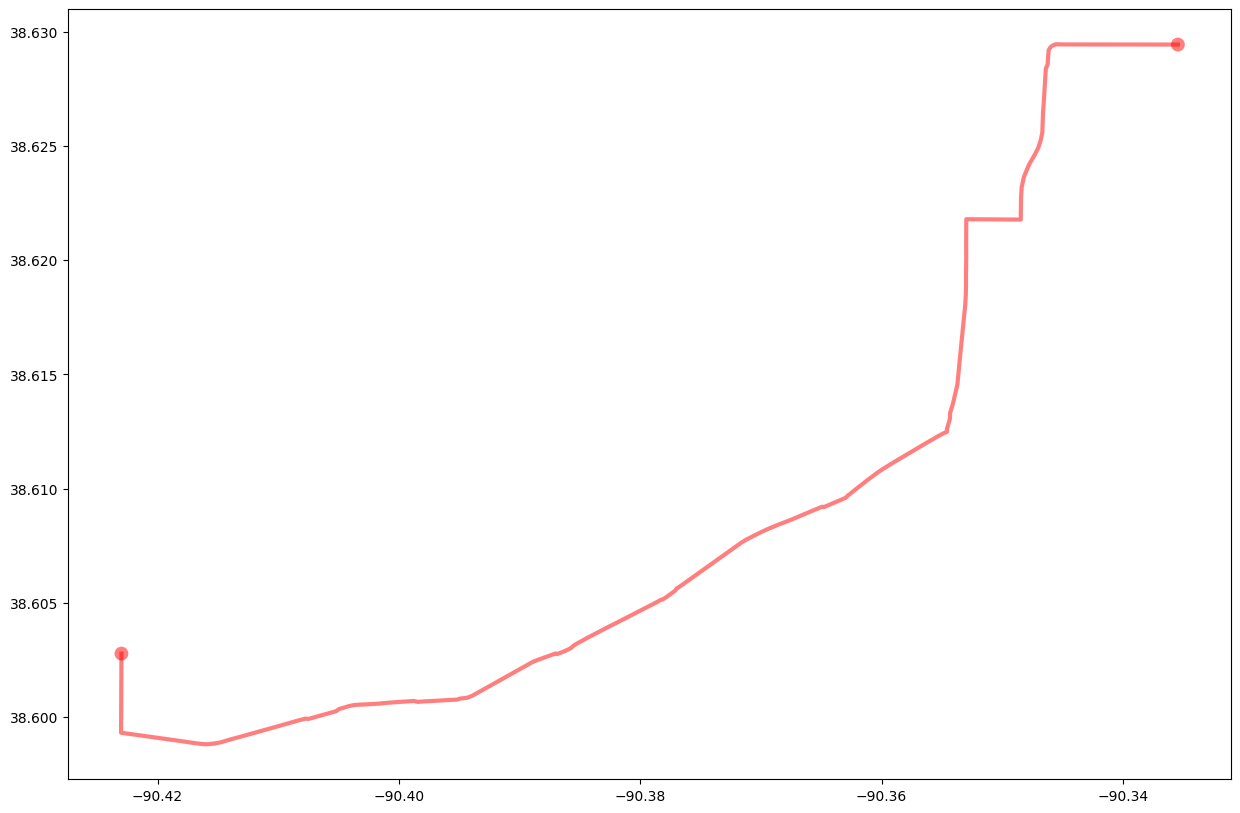

Route extracted with 101 nodes and 100 edges
Route saved to race_track_centerline.geojson


/var/folders/24/y__mx0xd3rn5g48sf3wlvf080000gn/T/ipykernel_70060/2853575291.py:49: PerformanceWarning: indexing past lexsort depth may impact performance.
  edges = gdf_edges.loc[(u, v)]
/opt/homebrew/lib/python3.11/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [16]:
import osmnx as ox
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, LineString
import pandas as pd

# Define start and end points
start_point = (38.60254, -90.42302)  # (lat, lon)
end_point = (38.62942, -90.33552)  # (lat, lon)

# Calculate center point and distance for graph_from_point
center_lat = (start_point[0] + end_point[0]) / 2
center_lon = (start_point[1] + end_point[1]) / 2
center_point = (center_lat, center_lon)

# Calculate distance in meters (approximately)
from haversine import haversine
dist_meters = haversine(start_point, end_point, unit='m') * 1.5  # Add 50% margin

print(f"Fetching OSM data centered at {center_point} with radius {dist_meters/1000:.2f} km")

# Get graph from center point with sufficient distance to include route
G = ox.graph_from_point(center_point, dist=dist_meters, network_type='drive')

# Find the nodes closest to our start and end points
start_node = ox.nearest_nodes(G, start_point[1], start_point[0])
end_node = ox.nearest_nodes(G, end_point[1], end_point[0])

# Find the shortest path between these nodes
route = ox.shortest_path(G, start_node, end_node)

# Plot the route
fig, ax = plt.subplots(figsize=(15, 10))
ox.plot_graph_route(G, route, route_color='red', route_linewidth=3, ax=ax)

# Save the figure
plt.savefig('pf_race_track_route.png', dpi=300)
plt.close()

# Extract the route as a GeoDataFrame
# For OSMnx 2.0.6, we need to manually create the route GeoDataFrame
gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)

# Get the edges for the route
route_edges = []
for u, v in zip(route[:-1], route[1:]):
    # There might be multiple edges between the same nodes (different directions, etc.)
    # Get all edges between u and v
    edges = gdf_edges.loc[(u, v)]
    if isinstance(edges, pd.Series):
        # If there's only one edge, it will be a Series
        route_edges.append(edges)
    else:
        # If there are multiple edges, take the first one
        route_edges.append(edges.iloc[0])

# Convert list of edges to GeoDataFrame
if len(route_edges) > 0:
    route_gdf = gpd.GeoDataFrame(route_edges)
else:
    print("Warning: No edges found for route")
    route_gdf = gpd.GeoDataFrame()

# Save to file for further processing
if not route_gdf.empty:
    route_gdf.to_file('pf_race_track_centerline.geojson', driver='GeoJSON')
    print(f"Route extracted with {len(route)} nodes and {len(route_gdf)} edges")
    print(f"Route saved to race_track_centerline.geojson")
else:
    print("Could not save empty route")

## make the route a race track

In [20]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, Polygon, MultiLineString
from shapely.ops import linemerge
import math
import json

# Load the race track centerline from GeoJSON
track_path = 'race_track_centerline_with_waypoints.geojson'
track_gdf = gpd.read_file(track_path)

print(f"Loaded track with {len(track_gdf)} points")

# Define vehicle performance characteristics
vehicles = {
    'Subaru Forester': {
        'color': '#0078C8',  # Subaru blue
        'top_speed': 30,     # m/s (about 108 km/h)
        'acceleration': 3.0, # m/s²
        'braking': 6.0,      # m/s²
        'max_lateral_g': 0.8, # maximum cornering G force
        'weight': 1700,      # kg
        'power': 136000,     # W (182 hp)
        'aero_drag': 0.40,   # drag coefficient
        'width': 3.0,        # visual width on track (m)
    },
    'McLaren': {
        'color': '#FF7400',  # McLaren orange
        'top_speed': 85,     # m/s (about 306 km/h)
        'acceleration': 8.0, # m/s²
        'braking': 12.0,     # m/s² 
        'max_lateral_g': 1.7, # maximum cornering G force
        'weight': 1400,      # kg
        'power': 530000,     # W (710 hp)
        'aero_drag': 0.32,   # drag coefficient
        'width': 3.0,        # visual width on track (m)
    }
}

# Create a coordinate-normalized track for easier calculations
def normalize_track_coordinates(track_gdf):
    """Convert track coordinates to a local XY system in meters"""
    # Extract points from track GeoDataFrame
    points = []
    
    for _, row in track_gdf.iterrows():
        geom = row.geometry
        if isinstance(geom, Point):
            points.append((geom.x, geom.y))
    
    # Get first point as origin
    origin_lat = points[0][1]  # y coordinate (latitude)
    origin_lon = points[0][0]  # x coordinate (longitude)
    
    # Convert to XY coords (rough approximation)
    # 111,320 meters per degree of latitude
    # 111,320 * cos(latitude) meters per degree of longitude
    cos_lat = np.cos(np.radians(origin_lat))
    
    xy_points = []
    for lon, lat in points:
        # Calculate distances in meters
        y = (lat - origin_lat) * 111320
        x = (lon - origin_lon) * 111320 * cos_lat
        
        xy_points.append((x, y))
    
    return xy_points

# Function to create a widened track from centerline
def create_track_boundaries(xy_points, track_width=12):
    """Create left and right boundaries for the track"""
    # Convert points to a LineString
    centerline = LineString(xy_points)
    
    # Create parallel lines at half track width distance
    try:
        left_boundary = centerline.parallel_offset(track_width/2, 'left', join_style=1)
        right_boundary = centerline.parallel_offset(track_width/2, 'right', join_style=1)
        
        # Handle MultiLineString results
        if isinstance(left_boundary, MultiLineString):
            # Try to merge the lines
            left_boundary = linemerge(left_boundary)
            # If still multi, take the longest piece
            if isinstance(left_boundary, MultiLineString):
                longest_piece = max(left_boundary.geoms, key=lambda line: line.length)
                left_boundary = longest_piece
                
        if isinstance(right_boundary, MultiLineString):
            # Try to merge the lines
            right_boundary = linemerge(right_boundary)
            # If still multi, take the longest piece
            if isinstance(right_boundary, MultiLineString):
                longest_piece = max(right_boundary.geoms, key=lambda line: line.length)
                right_boundary = longest_piece
        
        # Get the points from boundaries
        left_points = list(left_boundary.coords)
        right_points = list(right_boundary.coords)
        
        # Check direction consistency
        if len(left_points) > 0 and len(right_points) > 0:
            # Calculate distances between first and last points of each boundary
            left_first_to_right_first = math.sqrt((left_points[0][0] - right_points[0][0])**2 + 
                                                 (left_points[0][1] - right_points[0][1])**2)
            left_first_to_right_last = math.sqrt((left_points[0][0] - right_points[-1][0])**2 + 
                                                (left_points[0][1] - right_points[-1][1])**2)
            
            # If first point of left is closer to last point of right, reverse right
            if left_first_to_right_last < left_first_to_right_first:
                right_points = right_points[::-1]
                right_boundary = LineString(right_points)
                
        return centerline, left_boundary, right_boundary
    
    except Exception as e:
        print(f"Error creating track boundaries: {e}")
        # Fallback: Create simplified boundaries
        print("Creating simplified track boundaries...")
        
        # Create simplified boundaries manually
        left_points = []
        right_points = []
        
        for i in range(len(xy_points)-1):
            p1 = xy_points[i]
            p2 = xy_points[i+1]
            
            # Calculate direction vector
            dx = p2[0] - p1[0]
            dy = p2[1] - p1[1]
            
            # Normalize vector
            length = math.sqrt(dx*dx + dy*dy)
            if length > 0:
                dx /= length
                dy /= length
            
            # Perpendicular vector (90 degrees CCW)
            nx = -dy
            ny = dx
            
            # Create offset points
            left_points.append((p1[0] + nx * track_width/2, 
                                p1[1] + ny * track_width/2))
            right_points.append((p1[0] - nx * track_width/2, 
                                 p1[1] - ny * track_width/2))
        
        # Add last point
        left_points.append((xy_points[-1][0] + nx * track_width/2, 
                            xy_points[-1][1] + ny * track_width/2))
        right_points.append((xy_points[-1][0] - nx * track_width/2, 
                             xy_points[-1][1] - ny * track_width/2))
        
        left_boundary = LineString(left_points)
        right_boundary = LineString(right_points)
        
        return centerline, left_boundary, right_boundary

# Calculate racing line for each vehicle
def calculate_racing_line(centerline, left_bound, right_bound, vehicle):
    """Calculate optimal racing line based on vehicle characteristics"""
    # Extract centerline points
    points = list(centerline.coords)
    
    # For each point, calculate curvature to determine optimal line
    racing_line_points = []
    n_points = len(points)
    
    for i in range(n_points):
        # Get previous, current, and next points
        prev_idx = (i - 1) % n_points
        next_idx = (i + 1) % n_points
        
        prev_pt = points[prev_idx]
        curr_pt = points[i]
        next_pt = points[next_idx]
        
        # Calculate vectors
        v1 = (curr_pt[0] - prev_pt[0], curr_pt[1] - prev_pt[1])
        v2 = (next_pt[0] - curr_pt[0], next_pt[1] - curr_pt[1])
        
        # Calculate angle between vectors
        dot_product = v1[0]*v2[0] + v1[1]*v2[1]
        mag1 = math.sqrt(v1[0]**2 + v1[1]**2)
        mag2 = math.sqrt(v2[0]**2 + v2[1]**2)
        
        # Avoid division by zero
        if mag1 * mag2 == 0:
            angle = 0
        else:
            angle = math.acos(max(-1, min(1, dot_product / (mag1 * mag2))))
        
        # Direction of turn (left/right)
        cross_product = v1[0]*v2[1] - v1[1]*v2[0]
        turn_direction = 1 if cross_product > 0 else -1  # 1 for left, -1 for right
        
        # Curvature (inverse of radius)
        if angle == 0:
            curvature = 0
        else:
            # Approximate curvature
            curvature = 2 * math.sin(angle/2) / ((mag1 + mag2)/2)
        
        # Calculate racing line offset based on curvature and vehicle
        # Higher performance vehicles can take more direct lines through corners
        max_offset = 0.8 * vehicle['max_lateral_g'] / (1 + abs(curvature) * 10)
        
        # Scale to track width
        track_width = 12  # Meters
        offset = max_offset * track_width/2 * turn_direction * -1
        
        # Calculate point on racing line
        norm_vector = (-v1[1]/mag1, v1[0]/mag1)  # Normalized perpendicular vector
        racing_pt = (curr_pt[0] + norm_vector[0] * offset, 
                     curr_pt[1] + norm_vector[1] * offset)
        
        racing_line_points.append(racing_pt)
    
    return LineString(racing_line_points)

# Calculate speed profile for a vehicle on its racing line
def calculate_speed_profile(racing_line, vehicle):
    """Calculate speed at each point based on curvature and vehicle capabilities"""
    points = list(racing_line.coords)
    speeds = []
    n_points = len(points)
    
    for i in range(n_points):
        # Calculate local curvature (using 3 points)
        prev_idx = (i - 1) % n_points
        next_idx = (i + 1) % n_points
        
        prev_pt = points[prev_idx]
        curr_pt = points[i]
        next_pt = points[next_idx]
        
        # Calculate vectors
        v1 = (curr_pt[0] - prev_pt[0], curr_pt[1] - prev_pt[1])
        v2 = (next_pt[0] - curr_pt[0], next_pt[1] - curr_pt[1])
        
        # Calculate angle
        dot_product = v1[0]*v2[0] + v1[1]*v2[1]
        mag1 = math.sqrt(v1[0]**2 + v1[1]**2)
        mag2 = math.sqrt(v2[0]**2 + v2[1]**2)
        
        if mag1 * mag2 == 0:
            curvature = 0
        else:
            angle = math.acos(max(-1, min(1, dot_product / (mag1 * mag2))))
            curvature = 2 * math.sin(angle/2) / ((mag1 + mag2)/2) if angle != 0 else 0
        
        # Calculate max speed based on lateral G and curvature
        if curvature == 0:
            corner_limited_speed = vehicle['top_speed']
        else:
            # v² = a_lateral / curvature
            corner_limited_speed = math.sqrt(vehicle['max_lateral_g'] * 9.81 / abs(curvature))
            
        # Limit to vehicle's top speed
        max_speed = min(corner_limited_speed, vehicle['top_speed'])
        speeds.append(max_speed)
    
    return speeds

# Create a visualization of the race track with racing lines
def visualize_race_track(centerline, left_bound, right_bound, racing_lines, speeds_dict):
    fig, ax = plt.subplots(figsize=(15, 10))
    
    # Extract coordinates
    left_coords = list(left_bound.coords)
    right_coords = list(right_bound.coords)
    
    # Create a polygon for the track (connect left and right boundaries)
    track_poly = Polygon(left_coords + right_coords[::-1])
    
    # Plot track
    x, y = track_poly.exterior.xy
    ax.fill(x, y, alpha=0.3, fc='gray', ec='none')
    
    # Plot centerline
    x, y = centerline.xy
    ax.plot(x, y, 'k--', alpha=0.5, linewidth=1)
    
    # Plot racing lines with speed color gradients
    for vehicle_name, racing_line in racing_lines.items():
        speeds = speeds_dict[vehicle_name]
        points = list(racing_line.coords)
        
        # Normalize speeds for color mapping
        norm_speeds = [(s/vehicles[vehicle_name]['top_speed']) for s in speeds]
        
        # Plot segments with color based on speed
        for i in range(len(points)-1):
            x1, y1 = points[i]
            x2, y2 = points[i+1]
            
            # Color based on speed (green = fast, red = slow)
            speed_color = plt.cm.RdYlGn(norm_speeds[i])
            
            ax.plot([x1, x2], [y1, y2], color=vehicles[vehicle_name]['color'], 
                   linewidth=3, alpha=0.8)
    
    # Add start/finish line
    start_x, start_y = list(centerline.coords)[0]
    normal_vec = (right_coords[0][0] - left_coords[0][0], right_coords[0][1] - left_coords[0][1])
    length = math.sqrt(normal_vec[0]**2 + normal_vec[1]**2)
    unit_normal = (normal_vec[0]/length, normal_vec[1]/length)
    
    ax.plot([left_coords[0][0], right_coords[0][0]], 
            [left_coords[0][1], right_coords[0][1]], 'w-', linewidth=3)
    
    # Add a legend
    for vehicle_name, vehicle in vehicles.items():
        ax.plot([], [], color=vehicle['color'], linewidth=3, 
                label=f"{vehicle_name} ({int(vehicle['top_speed']*3.6)} km/h max)")
    
    ax.legend(loc='upper right')
    
    # Set equal aspect ratio and remove axes
    ax.set_aspect('equal')
    ax.set_title('Race Track: Subaru Forester vs. McLaren', fontsize=16)
    ax.set_xlabel('Distance (meters)')
    ax.set_ylabel('Distance (meters)')
    
    # Save figure
    plt.savefig('race_track_simulation.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    return fig

# Create a JSON data structure for interactive visualization
def create_race_data_json(centerline, left_bound, right_bound, racing_lines, speeds_dict):
    race_data = {
        "track": {
            "centerline": list(centerline.coords),
            "left_boundary": list(left_bound.coords),
            "right_boundary": list(right_bound.coords),
            "width": 12,  # meters
        },
        "vehicles": {}
    }
    
    # Add vehicle data
    for vehicle_name, vehicle in vehicles.items():
        racing_line = racing_lines[vehicle_name]
        speeds = speeds_dict[vehicle_name]
        
        # Calculate times based on speeds
        points = list(racing_line.coords)
        distances = []
        times = []
        total_distance = 0
        total_time = 0
        
        for i in range(1, len(points)):
            p1 = points[i-1]
            p2 = points[i]
            
            # Distance between points
            dist = math.sqrt((p2[0]-p1[0])**2 + (p2[1]-p1[1])**2)
            total_distance += dist
            
            # Average speed between points (m/s)
            avg_speed = (speeds[i-1] + speeds[i]) / 2
            
            # Time to traverse this segment (s)
            if avg_speed > 0.1:  # Avoid division by zero
                time = dist / avg_speed
            else:
                time = 10  # Default if speed is too low
            
            total_time += time
            
            distances.append(total_distance)
            times.append(total_time)
        
        race_data["vehicles"][vehicle_name] = {
            "racing_line": list(racing_line.coords),
            "speeds": speeds,
            "distances": distances,
            "times": times,
            "total_time": total_time,
            "color": vehicle["color"],
            "properties": {k: v for k, v in vehicle.items() if k != "color"}
        }
    
    return race_data

# Save race data to Kepler.gl compatible CSV (continued)
def save_kepler_csv(racing_lines, speeds_dict, track_gdf, output_file='race_track_simulation.csv'):
    # Get origin coordinates for converting back to lat/lon
    origin_lat = track_gdf.iloc[0].geometry.y
    origin_lon = track_gdf.iloc[0].geometry.x
    cos_lat = np.cos(np.radians(origin_lat))
    
    # Combine all racing line points into one DataFrame
    all_data = []
    
    for vehicle_name, racing_line in racing_lines.items():
        points = list(racing_line.coords)
        speeds = speeds_dict[vehicle_name]
        
        # Calculate progressive times and distances
        times = []
        distances = []
        total_distance = 0
        total_time = 0
        
        for i in range(len(points)):
            if i > 0:
                p1 = points[i-1]
                p2 = points[i]
                
                # Distance between points
                dist = math.sqrt((p2[0]-p1[0])**2 + (p2[1]-p1[1])**2)
                total_distance += dist
                
                # Average speed between points (m/s)
                avg_speed = (speeds[i-1] + speeds[i]) / 2
                
                # Time to traverse this segment (s)
                if avg_speed > 0.1:
                    time = dist / avg_speed
                else:
                    time = 10
                
                total_time += time
            else:
                # First point
                total_distance = 0
                total_time = 0
            
            # Convert xy coordinates back to lat/lon
            x, y = points[i]
            lon = origin_lon + (x / (111320 * cos_lat))
            lat = origin_lat + (y / 111320)
            
            # Add to data
            all_data.append({
                'vehicle': vehicle_name,
                'latitude': lat,
                'longitude': lon,
                'point_index': i,
                'total_distance': total_distance,
                'elapsed_time': total_time,
                'speed': speeds[i],
                'speed_kph': speeds[i] * 3.6,  # Convert m/s to km/h
                'seconds_elapsed': total_time  # For Kepler timeline
            })
    
    # Convert to DataFrame and save
    df = pd.DataFrame(all_data)
    df.to_csv(output_file, index=False)
    print(f"Saved racing simulation to {output_file}")
    return df

# Main function to create the race track simulation
def create_race_track_simulation(track_path):
    print("Loading track data...")
    track_gdf = gpd.read_file(track_path)
    
    print("Converting to local coordinates...")
    xy_points = normalize_track_coordinates(track_gdf)
    
    print("Creating track boundaries...")
    centerline, left_bound, right_bound = create_track_boundaries(xy_points, track_width=12)
    
    # Calculate racing lines and speed profiles for each vehicle
    racing_lines = {}
    speeds_dict = {}
    
    for vehicle_name, vehicle in vehicles.items():
        print(f"Calculating racing line for {vehicle_name}...")
        racing_line = calculate_racing_line(centerline, left_bound, right_bound, vehicle)
        racing_lines[vehicle_name] = racing_line
        
        print(f"Calculating speed profile for {vehicle_name}...")
        speeds = calculate_speed_profile(racing_line, vehicle)
        speeds_dict[vehicle_name] = speeds
    
    # Compare lap times
    lap_times = {}
    for vehicle_name, speeds in speeds_dict.items():
        racing_line = racing_lines[vehicle_name]
        points = list(racing_line.coords)
        
        # Calculate total distance and time
        total_distance = 0
        total_time = 0
        
        for i in range(1, len(points)):
            p1 = points[i-1]
            p2 = points[i]
            
            # Distance between points
            dist = math.sqrt((p2[0]-p1[0])**2 + (p2[1]-p1[1])**2)
            
            # Average speed
            avg_speed = (speeds[i-1] + speeds[i]) / 2
            if avg_speed > 0.1:
                time = dist / avg_speed
            else:
                time = 10
                
            total_distance += dist
            total_time += time
        
        lap_times[vehicle_name] = (total_time, total_distance)
    
    # Print lap time comparison
    print("\n=== Lap Time Comparison ===")
    for vehicle_name, (time, distance) in lap_times.items():
        print(f"{vehicle_name}: {time:.1f} seconds, {distance:.0f} meters, Avg speed: {(distance/time)*3.6:.1f} km/h")
    
    # Visualize the race track
    print("\nCreating race track visualization...")
    fig = visualize_race_track(centerline, left_bound, right_bound, racing_lines, speeds_dict)
    
    # Save race data for interactive visualization
    print("Creating race data for interactive visualization...")
    race_data = create_race_data_json(centerline, left_bound, right_bound, racing_lines, speeds_dict)
    
    with open("race_track_simulation.json", "w") as f:
        json.dump(race_data, f)
    
    # Save Kepler.gl compatible CSV
    print("Saving Kepler.gl compatible CSV...")
    df_kepler = save_kepler_csv(racing_lines, speeds_dict, track_gdf)
    
    return fig, race_data, df_kepler

# Run the simulation
if __name__ == "__main__":
    track_path = "race_track_centerline_with_waypoints.geojson"
    fig, race_data, df_kepler = create_race_track_simulation(track_path)
    
    # Calculate winner and time difference
    subaru_time = race_data["vehicles"]["Subaru Forester"]["total_time"]
    mclaren_time = race_data["vehicles"]["McLaren"]["total_time"]
    
    time_diff = abs(subaru_time - mclaren_time)
    winner = "Subaru Forester" if subaru_time < mclaren_time else "McLaren"
    
    print(f"\nRace winner: {winner} by {time_diff:.1f} seconds!")
    print("Race simulation complete! Check the output files:")
    print("1. race_track_simulation.png - Visual representation of the track with racing lines")
    print("2. race_track_simulation.json - JSON data with detailed race information")
    print("3. race_track_simulation.csv - CSV file compatible with Kepler.gl for visualization")

Loaded track with 200 points
Loading track data...
Converting to local coordinates...
Creating track boundaries...
Calculating racing line for Subaru Forester...
Calculating speed profile for Subaru Forester...
Calculating racing line for McLaren...
Calculating speed profile for McLaren...

=== Lap Time Comparison ===
Subaru Forester: 866.7 seconds, 25179 meters, Avg speed: 104.6 km/h
McLaren: 392.9 seconds, 25520 meters, Avg speed: 233.8 km/h

Creating race track visualization...
Creating race data for interactive visualization...
Saving Kepler.gl compatible CSV...
Saved racing simulation to race_track_simulation.csv

Race winner: McLaren by 473.8 seconds!
Race simulation complete! Check the output files:
1. race_track_simulation.png - Visual representation of the track with racing lines
2. race_track_simulation.json - JSON data with detailed race information
3. race_track_simulation.csv - CSV file compatible with Kepler.gl for visualization


Fetching OSM data...
Fetching OSM data centered at (38.61598, -90.37926999999999) with radius 16.34 km
Found nearest nodes: start=2434634916, end=5634509436
Found route with 101 nodes
Extracted 101 route points
Track visualization saved to race_track.png
Track data saved to race_track.geojson
Track data for Kepler.gl saved to race_track_kepler.csv
Track creation completed successfully!


/opt/homebrew/lib/python3.11/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


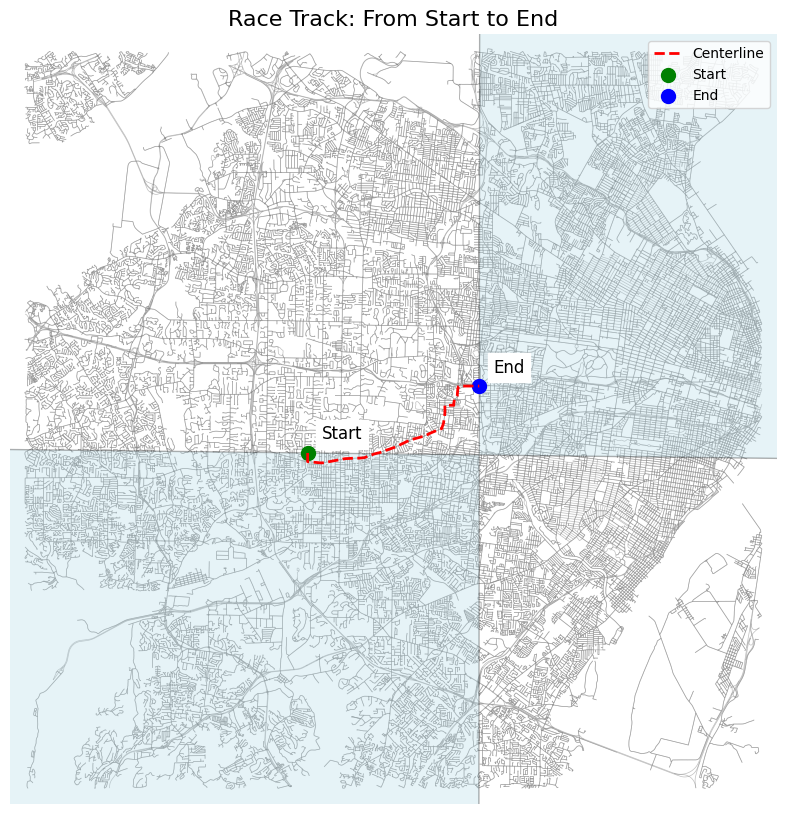

In [24]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, Polygon, MultiLineString
from shapely.ops import linemerge
import math
import osmnx as ox
import pandas as pd
import networkx as nx

# Define start and end points
start_point = (38.60254, -90.42302)  # (lat, lon)
end_point = (38.62942, -90.33552)  # (lat, lon)

def create_track_from_points(start_point, end_point):
    """Create a race track from start and end points using OSM data"""
    print("Fetching OSM data...")
    
    # Calculate center point and distance for graph_from_point
    center_lat = (start_point[0] + end_point[0]) / 2
    center_lon = (start_point[1] + end_point[1]) / 2
    center_point = (center_lat, center_lon)
    
    # Calculate distance in meters (approximately)
    from haversine import haversine
    dist_meters = haversine(start_point, end_point, unit='m') * 2.0  # Add 100% margin
    
    print(f"Fetching OSM data centered at {center_point} with radius {dist_meters/1000:.2f} km")
    
    # Get graph from center point
    G = ox.graph_from_point(center_point, dist=dist_meters, network_type='drive')
    
    # Find the nodes closest to our points
    start_node = ox.nearest_nodes(G, start_point[1], start_point[0])
    end_node = ox.nearest_nodes(G, end_point[1], end_point[0])
    
    print(f"Found nearest nodes: start={start_node}, end={end_node}")
    
    # Try to find the shortest path between these nodes
    try:
        route = ox.shortest_path(G, start_node, end_node)
        print(f"Found route with {len(route)} nodes")
    except nx.NetworkXNoPath:
        print("No path found between nodes. Adding intermediate waypoints...")
        # Add intermediate waypoints to help find a path
        waypoint = (38.61500, -90.38000)  # Example waypoint
        waypoint_node = ox.nearest_nodes(G, waypoint[1], waypoint[0])
        
        try:
            # Try to route through waypoint
            route1 = ox.shortest_path(G, start_node, waypoint_node)
            route2 = ox.shortest_path(G, waypoint_node, end_node)
            route = route1 + route2[1:]
            print(f"Found route through waypoint with {len(route)} nodes")
        except nx.NetworkXNoPath:
            print("Failed to find route even with waypoint. Using direct line.")
            # Fallback to direct line
            route = [start_node, end_node]
    
    # Extract nodes and edges
    gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)
    
    # Create a LineString of the route
    route_points = []
    for node in route:
        # Get coordinates from nodes GeoDataFrame
        x, y = gdf_nodes.loc[node].x, gdf_nodes.loc[node].y
        route_points.append((x, y))
    
    print(f"Extracted {len(route_points)} route points")
    
    # Create centerline
    centerline = LineString(route_points)
    
    # Create track boundaries
    track_width = 30  # meters - increased width to make it more visible
    
    # Create manual boundaries to avoid MultiLineString issues
    left_points = []
    right_points = []
    
    for i in range(len(route_points)-1):
        p1 = route_points[i]
        p2 = route_points[i+1]
        
        # Calculate direction vector
        dx = p2[0] - p1[0]
        dy = p2[1] - p1[1]
        
        # Normalize vector
        length = math.sqrt(dx*dx + dy*dy)
        if length > 0:
            dx /= length
            dy /= length
        else:
            # Skip duplicate points
            continue
        
        # Perpendicular vector (90 degrees CCW)
        nx = -dy
        ny = dx
        
        # Create offset points
        left_points.append((p1[0] + nx * track_width/2, p1[1] + ny * track_width/2))
        right_points.append((p1[0] - nx * track_width/2, p1[1] - ny * track_width/2))
    
    # Add last point if we have at least one point
    if len(route_points) > 1:
        p1 = route_points[-2]
        p2 = route_points[-1]
        dx = p2[0] - p1[0]
        dy = p2[1] - p1[1]
        length = math.sqrt(dx*dx + dy*dy)
        if length > 0:
            dx /= length
            dy /= length
            nx = -dy
            ny = dx
            left_points.append((p2[0] + nx * track_width/2, p2[1] + ny * track_width/2))
            right_points.append((p2[0] - nx * track_width/2, p2[1] - ny * track_width/2))
    
    left_boundary = LineString(left_points)
    right_boundary = LineString(right_points)
    
    # Create track polygon by connecting left and right boundaries
    track_coords = left_points + right_points[::-1] + [left_points[0]]
    track_polygon = Polygon(track_coords)
    
    # Visualize the track
    fig, ax = plt.subplots(figsize=(15, 10))
    
    # First plot the base map for context
    ox.plot_graph(G, ax=ax, node_size=0, edge_color='gray', edge_linewidth=0.5, edge_alpha=0.5, show=False)
    
    # Plot track
    x, y = track_polygon.exterior.xy
    ax.fill(x, y, alpha=0.3, fc='lightblue', ec='black', linewidth=1)
    
    # Plot centerline
    x, y = centerline.xy
    ax.plot(x, y, 'r--', linewidth=2, label='Centerline')
    
    # Plot start/end points
    ax.scatter([route_points[0][0]], [route_points[0][1]], color='green', s=100, label='Start')
    ax.scatter([route_points[-1][0]], [route_points[-1][1]], color='blue', s=100, label='End')
    
    # Add labels for start and end points
    ax.annotate("Start", (route_points[0][0], route_points[0][1]), 
                xytext=(10, 10), textcoords='offset points', 
                fontsize=12, color='black', backgroundcolor='white')
                
    ax.annotate("End", (route_points[-1][0], route_points[-1][1]), 
                xytext=(10, 10), textcoords='offset points', 
                fontsize=12, color='black', backgroundcolor='white')
    
    ax.set_title('Race Track: From Start to End', fontsize=16)
    ax.legend()
    
    # Save the track to a file
    plt.savefig('race_track.png', dpi=300, bbox_inches='tight')
    print("Track visualization saved to race_track.png")
    
    # Save the track data for further use
    track_data = {
        "type": "FeatureCollection",
        "features": [
            {
                "type": "Feature",
                "properties": {"type": "centerline"},
                "geometry": {
                    "type": "LineString",
                    "coordinates": route_points
                }
            },
            {
                "type": "Feature",
                "properties": {"type": "left_boundary"},
                "geometry": {
                    "type": "LineString",
                    "coordinates": left_points
                }
            },
            {
                "type": "Feature",
                "properties": {"type": "right_boundary"},
                "geometry": {
                    "type": "LineString",
                    "coordinates": right_points
                }
            }
        ]
    }
    
    # Save to GeoJSON
    gdf = gpd.GeoDataFrame.from_features(track_data['features'])
    gdf.to_file('race_track.geojson', driver='GeoJSON')
    print("Track data saved to race_track.geojson")
    
    # Create Kepler.gl compatible CSV
    # Combine all points into one DataFrame for Kepler visualization
    all_points = []
    
    # Add centerline points
    for i, point in enumerate(route_points):
        all_points.append({
            'longitude': point[0],
            'latitude': point[1],
            'point_type': 'start' if i == 0 else ('end' if i == len(route_points)-1 else 'centerline'),
            'seconds_elapsed': i  # For animation in Kepler
        })
    
    # Add left boundary points
    for i, point in enumerate(left_points):
        all_points.append({
            'longitude': point[0],
            'latitude': point[1],
            'point_type': 'left_boundary',
            'seconds_elapsed': i
        })
    
    # Add right boundary points
    for i, point in enumerate(right_points):
        all_points.append({
            'longitude': point[0],
            'latitude': point[1],
            'point_type': 'right_boundary',
            'seconds_elapsed': i
        })
    
    # Convert to DataFrame and save
    df = pd.DataFrame(all_points)
    df.to_csv('race_track_kepler.csv', index=False)
    print("Track data for Kepler.gl saved to race_track_kepler.csv")
    
    return centerline, left_boundary, right_boundary, track_polygon, G, route

# Create the track
try:
    centerline, left_boundary, right_boundary, track_polygon, G, route = create_track_from_points(start_point, end_point)
    print("Track creation completed successfully!")
except Exception as e:
    import traceback
    print(f"Error creating track: {e}")
    traceback.print_exc()

In [23]:
import pandas as pd
import numpy as np
from math import sin, cos, sqrt, atan2, radians

# Function to calculate distance between two points in meters using the Haversine formula
def haversine_distance(lat1, lon1, lat2, lon2):
    # Approximate radius of earth in meters
    R = 6371.0 * 1000
    
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    
    distance = R * c
    return distance

# Function to generate point at distance along a line segment
def intermediate_point(lat1, lon1, lat2, lon2, distance_from_start, total_distance):
    if total_distance == 0:
        return lat1, lon1
    
    fraction = distance_from_start / total_distance
    
    # Linear interpolation
    lat = lat1 + fraction * (lat2 - lat1)
    lon = lon1 + fraction * (lon2 - lon1)
    
    return lat, lon

# Load the race track data
df = pd.read_csv('race_track_kepler.csv')

# Define the distance between points (in meters)
distance_between_points = 5  # Adjust this value as needed

# Initialize the list for equidistant points
equidistant_points = []
point_id = 0

# Process each segment between consecutive track points
for i in range(len(df) - 1):
    lat1, lon1 = df.iloc[i]['latitude'], df.iloc[i]['longitude']
    lat2, lon2 = df.iloc[i+1]['latitude'], df.iloc[i+1]['longitude']
    
    # Calculate distance for this segment
    segment_distance = haversine_distance(lat1, lon1, lat2, lon2)
    
    # Calculate number of points to place on this segment
    num_points = int(segment_distance / distance_between_points)
    
    # Add the starting point
    if i == 0:
        equidistant_points.append({
            'id': point_id,
            'latitude': lat1,
            'longitude': lon1,
            'original_point': True
        })
        point_id += 1
    
    # Add intermediate points
    for j in range(1, num_points + 1):
        distance_from_start = j * distance_between_points
        if distance_from_start < segment_distance:
            new_lat, new_lon = intermediate_point(lat1, lon1, lat2, lon2, distance_from_start, segment_distance)
            equidistant_points.append({
                'id': point_id,
                'latitude': new_lat,
                'longitude': new_lon,
                'original_point': False
            })
            point_id += 1
    
    # Add the end point of the segment
    equidistant_points.append({
        'id': point_id,
        'latitude': lat2,
        'longitude': lon2,
        'original_point': True
    })
    point_id += 1

# Create a new dataframe with the equidistant points
result_df = pd.DataFrame(equidistant_points)

# Save to CSV
result_df.to_csv('race_track_equidistant.csv', index=False)
print(f"Created {len(result_df)} equidistant points at approximately {distance_between_points} meter intervals")
print("Data saved to race_track_equidistant.csv")

Created 7801678 equidistant points at approximately 5 meter intervals
Data saved to race_track_equidistant.csv


In [25]:
import folium
import json

# Load GeoJSON file
with open('race_track.geojson', 'r') as f:
    geojson_data = json.load(f)

# Create a map centered at an approximate location of your track
# We'll extract the first coordinate from the GeoJSON for centering
try:
    if 'features' in geojson_data and len(geojson_data['features']) > 0:
        if geojson_data['features'][0]['geometry']['type'] == 'LineString':
            first_coord = geojson_data['features'][0]['geometry']['coordinates'][0]
            center = [first_coord[1], first_coord[0]]  # [lat, lon]
        else:
            # Default center if not LineString
            center = [0, 0]
    else:
        # If it's a direct geometry without features array
        if geojson_data.get('type') == 'LineString' and 'coordinates' in geojson_data:
            first_coord = geojson_data['coordinates'][0]
            center = [first_coord[1], first_coord[0]]  # [lat, lon]
        else:
            center = [0, 0]
except:
    # Default center if anything goes wrong
    center = [0, 0]

# Create a map
m = folium.Map(location=center, zoom_start=14)

# Add the GeoJSON to the map
folium.GeoJson(
    geojson_data,
    name='Race Track',
    style_function=lambda x: {
        'color': 'red',
        'weight': 3,
        'opacity': 0.7
    }
).add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

# Save the map
m.save('race_track_visualization.html')

print("Map saved as 'race_track_visualization.html'. Open it in your web browser to view the track.")

Map saved as 'race_track_visualization.html'. Open it in your web browser to view the track.


In [26]:
import geopandas as gpd
import numpy as np
from shapely.geometry import LineString, Polygon, Point
from shapely.ops import unary_union
import math
from scipy.interpolate import splprep, splev

def load_centerline(geojson_file):
    """Load the centerline from GeoJSON file"""
    gdf = gpd.read_file(geojson_file)
    # Extract the first geometry (assuming it's a LineString)
    if len(gdf) > 0:
        return gdf.iloc[0].geometry
    return None

def smooth_line(line, smoothness=100):
    """Apply spline interpolation to smooth a line"""
    coords = np.array(line.coords)
    
    # Check if the line has enough points for smoothing
    if len(coords) < 4:
        return line
    
    # For closed lines, add the first point to the end
    closed = np.allclose(coords[0], coords[-1])
    if closed:
        coords = np.append(coords, [coords[0]], axis=0)
    
    # Create a spline representation of the line
    tck, u = splprep([coords[:, 0], coords[:, 1]], s=smoothness, k=3, per=closed)
    
    # Create more points than the original to get a smoother curve
    u_new = np.linspace(0, 1, 1000)
    new_coords = splev(u_new, tck)
    
    # Convert back to LineString
    return LineString(zip(new_coords[0], new_coords[1]))

def perpendicular_offset(point, prev_point, next_point, width):
    """Calculate perpendicular offset points for track width"""
    # Calculate direction vector
    if prev_point:
        dx1 = point[0] - prev_point[0]
        dy1 = point[1] - prev_point[1]
    else:
        dx1, dy1 = 0, 0
        
    if next_point:
        dx2 = next_point[0] - point[0]
        dy2 = next_point[1] - point[1]
    else:
        dx2, dy2 = 0, 0
    
    # Average direction vector
    dx = (dx1 + dx2) / 2 if (dx1 or dx2) else 0
    dy = (dy1 + dy2) / 2 if (dy1 or dy2) else 0
    
    # Normalize
    length = math.sqrt(dx*dx + dy*dy)
    if length > 0:
        dx /= length
        dy /= length
    
    # Perpendicular vector (rotate 90 degrees)
    perpendicular_x = -dy
    perpendicular_y = dx
    
    # Calculate offset points
    left_point = (point[0] + perpendicular_x * width/2, 
                  point[1] + perpendicular_y * width/2)
    right_point = (point[0] - perpendicular_x * width/2, 
                   point[1] - perpendicular_y * width/2)
    
    return left_point, right_point

def create_track_edges(centerline, width=10):
    """Create left and right track edges from centerline"""
    coords = list(centerline.coords)
    left_edge_points = []
    right_edge_points = []
    
    for i in range(len(coords)):
        point = coords[i]
        prev_point = coords[i-1] if i > 0 else None
        next_point = coords[i+1] if i < len(coords)-1 else None
        
        left_point, right_point = perpendicular_offset(point, prev_point, next_point, width)
        left_edge_points.append(left_point)
        right_edge_points.append(right_point)
    
    left_edge = LineString(left_edge_points)
    right_edge = LineString(right_edge_points)
    
    return left_edge, right_edge

def create_track_polygon(left_edge, right_edge):
    """Create a polygon representing the race track"""
    # Combine left edge (forward) and right edge (backward)
    track_outline = list(left_edge.coords) + list(reversed(right_edge.coords))
    return Polygon(track_outline)

def main():
    # Parameters
    input_file = "race_track.geojson"
    output_file = "full_race_track.geojson"
    track_width = 15  # in meters
    smoothness = 5000  # Higher values = smoother track
    
    # Load centerline
    centerline = load_centerline(input_file)
    if not centerline:
        print("Error: Could not load centerline from GeoJSON")
        return
    
    # Smooth the centerline
    print("Smoothing centerline...")
    smooth_centerline = smooth_line(centerline, smoothness)
    
    # Create track edges
    print("Creating track edges...")
    left_edge, right_edge = create_track_edges(smooth_centerline, track_width)
    
    # Smooth the edges
    smooth_left_edge = smooth_line(left_edge, smoothness)
    smooth_right_edge = smooth_line(right_edge, smoothness)
    
    # Create track polygon
    print("Creating track polygon...")
    track_polygon = create_track_polygon(smooth_left_edge, smooth_right_edge)
    
    # Create GeoDataFrame with the track polygon
    track_gdf = gpd.GeoDataFrame({'name': ['Race Track'], 
                                  'width': [track_width]}, 
                                 geometry=[track_polygon], 
                                 crs="EPSG:4326")
    
    # Save to GeoJSON
    track_gdf.to_file(output_file, driver="GeoJSON")
    print(f"Track created and saved to {output_file}")
    
    # Also save centerline and edges separately for visualization
    centerline_gdf = gpd.GeoDataFrame({'name': ['Center Line']}, 
                                     geometry=[smooth_centerline], 
                                     crs="EPSG:4326")
    edges_gdf = gpd.GeoDataFrame({'name': ['Left Edge', 'Right Edge']}, 
                               geometry=[smooth_left_edge, smooth_right_edge], 
                               crs="EPSG:4326")
    
    centerline_gdf.to_file("track_centerline.geojson", driver="GeoJSON")
    edges_gdf.to_file("track_edges.geojson", driver="GeoJSON")
    print("Additional files created: track_centerline.geojson, track_edges.geojson")

if __name__ == "__main__":
    main()

Smoothing centerline...
Creating track edges...
Creating track polygon...
Track created and saved to full_race_track.geojson
Additional files created: track_centerline.geojson, track_edges.geojson
